In [1]:
# ── Standard library ─────────────────────────────────────────────────
import json
import logging
import os
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# ── Third-party ───────────────────────────────────────────────────────
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

# ── Logging ────────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


In [2]:
# ── Model ─────────────────────────────────────────────────────────────
MODEL_NAME = "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct"
MAX_NEW_TOKENS = 4000

# ── Input file ────────────────────────────────────────────────────────
# Change this to the path of your test document (image or PDF)
FILE_PATH = "E:\\Anaconda3\\envs\\Judge-Assistant\\Case Sample\\Case_Sample(3).jpeg"

# ── PDF conversion DPI (only used for PDF files) ─────────────────────
PDF_DPI = 400

# ── Image restoration ─────────────────────────────────────────────────
MAX_IMAGE_DIMENSION = 4000
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

# ── OCR prompt ────────────────────────────────────────────────────────
OCR_PROMPT = (
    "You are a strict OCR engine transcribing Arabic legal documents. "
    "Transcribe exactly what is written in this image. "
    "Do NOT correct spelling, grammar, punctuation, or any perceived mistakes. "
    "Do NOT add or remove any words. "
    "If something looks like a typo or error, transcribe it exactly as-is. "
    "Preserve all text exactly character by character."
)

# ── HuggingFace login ─────────────────────────────────────────────────
from huggingface_hub import login

if token := os.environ.get("HF_TOKEN"):
    login(token)
    print("HuggingFace login successful.")
else:
    print("HF_TOKEN not set — skipping login. Private models will not be accessible.")

print(f"Model: {MODEL_NAME}")
print(f"File:  {FILE_PATH}")

HF_TOKEN not set — skipping login. Private models will not be accessible.
Model: NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct
File:  E:\Anaconda3\envs\Judge-Assistant\Case Sample\Case_Sample(3).jpeg


In [3]:
SUPPORTED_IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".webp"}
SUPPORTED_PDF_EXTENSIONS = {".pdf"}


def ingest_document(file_path: str, pdf_dpi: int = 400) -> List[Image.Image]:
    """
    Load a PDF or image file and return a list of PIL Images (one per page).
    """
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"File does not exist: {path}")
    if not path.is_file():
        raise ValueError(f"Path is not a file: {path}")

    suffix = path.suffix.lower()

    if suffix in SUPPORTED_PDF_EXTENSIONS:
        from pdf2image import convert_from_path
        print(f"Converting PDF to images at {pdf_dpi} DPI: {path.name}")
        pil_pages = convert_from_path(str(path), dpi=pdf_dpi)
        # Ensure RGB
        pages = [p.convert("RGB") if p.mode != "RGB" else p for p in pil_pages]
        print(f"PDF converted: {len(pages)} page(s)")
        return pages

    elif suffix in SUPPORTED_IMAGE_EXTENSIONS:
        print(f"Loading image: {path.name}")
        img = Image.open(path)
        img.verify()
        img = Image.open(path)  # re-open after verify
        if img.mode != "RGB":
            img = img.convert("RGB")
        print(f"Image loaded: {img.size[0]}x{img.size[1]}")
        return [img]

    else:
        raise ValueError(f"Unsupported file type: {suffix}")


# ── Run ingestion ─────────────────────────────────────────────────────
pages = ingest_document(FILE_PATH, pdf_dpi=PDF_DPI)
print(f"\nTotal pages: {len(pages)}")
for i, p in enumerate(pages):
    print(f"  Page {i + 1}: {p.size[0]}x{p.size[1]}")

Loading image: Case_Sample(3).jpeg
Image loaded: 899x1599

Total pages: 1
  Page 1: 899x1599


In [4]:
def restore_image(pil_image: Image.Image) -> Image.Image:
    """
    Lightweight image restoration:
    1. Convert to RGB if needed
    2. Resize if largest dimension > MAX_IMAGE_DIMENSION
    3. CLAHE contrast normalization
    """
    # 1. RGB conversion
    if pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")

    # 2. Resize if too large
    w, h = pil_image.size
    max_dim = max(w, h)
    if max_dim > MAX_IMAGE_DIMENSION:
        scale = MAX_IMAGE_DIMENSION / max_dim
        new_w = int(w * scale)
        new_h = int(h * scale)
        pil_image = pil_image.resize((new_w, new_h), Image.LANCZOS)
        print(f"   Resized: {w}x{h} -> {new_w}x{new_h}")

    # 3. CLAHE contrast normalization
    img_array = np.array(pil_image)
    lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_GRID_SIZE,
    )
    l_enhanced = clahe.apply(l_ch)
    merged = cv2.merge((l_enhanced, a_ch, b_ch))
    enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return Image.fromarray(enhanced_rgb)


# ── Run restoration ───────────────────────────────────────────────────
restored_pages: List[Image.Image] = []
for i, page in enumerate(pages):
    print(f"Restoring page {i + 1}...")
    restored_pages.append(restore_image(page))

print(f"\nRestoration complete: {len(restored_pages)} page(s)")

Restoring page 1...

Restoration complete: 1 page(s)


In [ ]:
# ── Perspective Correction (Edge-based) ─────────────────────────────
import numpy as np
import cv2
from PIL import Image
from typing import Tuple, List, Optional

# ── Config ─────────────────────────────────────────────────────────────
# Approach 1 (Contour Detection)
MIN_AREA_RATIO    = 0.35    # minimum contour area as fraction of image
CANNY_LOW         = 50     # Canny low threshold
CANNY_HIGH        = 150    # Canny high threshold
BLUR_KERNEL       = (5, 5) # Gaussian blur kernel size
DILATE_KERNEL     = (3, 3) # Dilation kernel size
DILATE_ITERATIONS = 1      # Dilation iterations
TOP_N_CONTOURS    = 5      # How many largest contours to check
APPROX_EPSILON_CD = 0.02   # Contour simplification tolerance
EXPAND_MARGIN_CD  = 0.02   # Quad expansion margin

# Approach 2 (Adaptive Threshold)
BLOCK_SIZE         = 35     # adaptive threshold block size (must be odd)
C_CONSTANT         = -10    # threshold constant (more negative = stricter)
CLOSE_KERNEL       = (30, 30)  # morphological close kernel
CLOSE_ITERATIONS   = 2        # close iterations
OPEN_KERNEL        = (15, 15)   # morphological open kernel
OPEN_ITERATIONS    = 1        # open iterations
APPROX_EPSILON_AT  = 0.02     # contour simplification tolerance
EXPAND_MARGIN_AT   = 0.02     # quad expansion margin

# ── Helpers ─────────────────────────────────────────────────────────────
def order_points(pts: np.ndarray) -> np.ndarray:
    """
    Order four corner points as: top-left, top-right, bottom-right, bottom-left.
    """
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left: smallest sum
    rect[2] = pts[np.argmax(s)]   # bottom-right: largest sum
    d = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(d)]   # top-right: smallest diff
    rect[3] = pts[np.argmax(d)]   # bottom-left: largest diff
    return rect


def expand_quad(pts: np.ndarray, img_shape: Tuple[int, ...], margin_pct: float = 0.02) -> np.ndarray:
    """
    Expand a quadrilateral outward from its center by margin_pct to avoid
    clipping text at the very edge of the page.
    """
    h, w = img_shape[:2]
    center = pts.mean(axis=0)
    expanded = center + (pts - center) * (1 + margin_pct)
    expanded[:, 0] = np.clip(expanded[:, 0], 0, w - 1)
    expanded[:, 1] = np.clip(expanded[:, 1], 0, h - 1)
    return expanded.astype(np.float32)


def detect_page_contour(img_array: np.ndarray) -> Optional[np.ndarray]:
    """
    Approach 1: Edge-based contour detection.
    Finds the largest quadrilateral contour that covers at least min_area_ratio
    of the image area. Returns 4 corner points or None.
    """
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
    edges = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)

    # Dilate edges to close gaps caused by shadows or low contrast
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, DILATE_KERNEL)
    edges = cv2.dilate(edges, kernel, iterations=DILATE_ITERATIONS)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    h, w = img_array.shape[:2]
    img_area = w * h

    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for contour in contours[:TOP_N_CONTOURS]:       
        area = cv2.contourArea(contour)
        if area < img_area * MIN_AREA_RATIO:
            continue

        peri = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, APPROX_EPSILON_CD * peri, True)

        if len(approx) == 4:
            return approx.reshape(4, 2)

    return None


def detect_page_threshold(img_array: np.ndarray) -> Optional[np.ndarray]:
    """
    Approach 2: Adaptive threshold fallback.
    Segments the light page from the darker background using adaptive thresholding,
    then finds the largest connected component and returns its bounding quad.
    """
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape[:2]
    img_area = w * h

    # Adaptive threshold: light page becomes white, dark background becomes black
    binary = cv2.adaptiveThreshold(
        gray, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 
        BLOCK_SIZE, 
        C_CONSTANT
    )

    # Morphological close to fill small gaps within the page
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, CLOSE_KERNEL)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=CLOSE_ITERATIONS)

    # Remove small noise blobs
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, OPEN_KERNEL)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_open, iterations=OPEN_ITERATIONS)

    # Find contours on the binary mask
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    # Pick the largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    if area < img_area * MIN_AREA_RATIO:
        return None

    # Try to approximate to 4 corners first
    peri = cv2.arcLength(largest, True)
    approx = cv2.approxPolyDP(largest, APPROX_EPSILON_AT * peri, True)

    if len(approx) == 4:
        return approx.reshape(4, 2)

    # Fall back to minAreaRect
    rect = cv2.minAreaRect(largest)
    box = cv2.boxPoints(rect)
    return box.astype(np.float32)


def _check_safety_guards(
    src_pts: np.ndarray,
    dst_w: int,
    dst_h: int,
    orig_w: int,
    orig_h: int,
    min_dim_ratio: float = 0.65,
    min_area_ratio: float = MIN_AREA_RATIO,
) -> Tuple[bool, str]:
    """
    Validate that the perspective correction result is not too aggressive.
    Returns (is_safe, reason).
    """
    # Check minimum dimensions
    if dst_w < 100 or dst_h < 100:
        return False, f'output too small ({dst_w}x{dst_h})'

    # Maximum crop ratio: output must be >= 70% of original in each axis
    w_ratio = dst_w / orig_w
    h_ratio = dst_h / orig_h
    if w_ratio < min_dim_ratio or h_ratio < min_dim_ratio:
        return False, f'crops too aggressively (w_ratio={w_ratio:.2f}, h_ratio={h_ratio:.2f})'

    # Minimum area ratio
    area_ratio = (dst_w * dst_h) / (orig_w * orig_h)
    if area_ratio < min_area_ratio:
        return False, f'output area too small ({area_ratio:.2f} of original)'

    # Aspect ratio sanity: if original is portrait, output should not be landscape
    orig_portrait = orig_h > orig_w
    out_portrait = dst_h > dst_w
    if orig_portrait and not out_portrait:
        # Allow a small tolerance for nearly-square results
        if dst_w / dst_h > 1.15:
            return False, 'portrait original became landscape output'

    return True, 'ok'


def perspective_correct(pil_image: Image.Image) -> Tuple[Image.Image, bool]:
    """
    Detect the physical page boundary using edge-based computer vision and
    dewarp the image. Uses a tiered fallback:
      1. Edge-based contour detection
      2. Adaptive threshold page mask
      3. Passthrough (return original unchanged)

    Returns the corrected PIL Image and a boolean indicating whether
    correction was applied.
    """
    img_array = np.array(pil_image)
    h, w = img_array.shape[:2]

    try:
        # Try approach 1: edge-based
        page_quad = detect_page_contour(img_array)
        method = 'edge-contour'

        # Try approach 2: adaptive threshold
        if page_quad is None:
            page_quad = detect_page_threshold(img_array)
            method = 'adaptive-threshold'

        # Approach 3: Passthrough
        if page_quad is None:
            print('   No page boundary detected by any method -- passing through.')
            return pil_image, False

        print(f'   Page boundary detected via {method}')

        # Expand the quad slightly to avoid clipping edge text
        page_quad = expand_quad(page_quad.astype(np.float32), img_array.shape, margin_pct=EXPAND_MARGIN_CD if method == 'edge-contour' else EXPAND_MARGIN_AT)

        # Order points and compute destination dimensions
        src_pts = order_points(page_quad)

        dst_w = int(max(
            np.linalg.norm(src_pts[1] - src_pts[0]),
            np.linalg.norm(src_pts[2] - src_pts[3]),
        ))
        dst_h = int(max(
            np.linalg.norm(src_pts[3] - src_pts[0]),
            np.linalg.norm(src_pts[2] - src_pts[1]),
        ))

        # Safety guards
        is_safe, reason = _check_safety_guards(src_pts, dst_w, dst_h, w, h)
        if not is_safe:
            print(f'   Safety guard triggered: {reason} -- passing through.')
            return pil_image, False

        dst_pts = np.array([
            [0,         0        ],
            [dst_w - 1, 0        ],
            [dst_w - 1, dst_h - 1],
            [0,         dst_h - 1],
        ], dtype=np.float32)

        M = cv2.getPerspectiveTransform(src_pts, dst_pts)
        warped = cv2.warpPerspective(
            img_array, M, (dst_w, dst_h),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(255, 255, 255),
        )

        print(f'   Perspective corrected ({method}): {w}x{h} -> {dst_w}x{dst_h}')
        return Image.fromarray(warped), True

    except Exception as exc:
        print(f'   Perspective correction failed: {exc} -- passing through original.')
        return pil_image, False


# ── Run perspective correction on all pages ────────────────────────────
corrected_pages: List[Image.Image] = []
page_corrections: List[bool] = []

for i, page in enumerate(restored_pages):
    print(f'Perspective correction -- page {i + 1}...')
    corrected, was_corrected = perspective_correct(page)
    corrected_pages.append(corrected)
    page_corrections.append(was_corrected)
    if not was_corrected:
        print(f'   Page {i + 1}: passed through unchanged.')

print(f'\nPerspective correction complete: {len(corrected_pages)} page(s)')
print(f'Corrected: {sum(page_corrections)} / {len(page_corrections)}')

Perspective correction -- page 1...
   Page boundary detected via adaptive-threshold
   Perspective corrected (adaptive-threshold): 899x1599 -> 898x1385

Perspective correction complete: 1 page(s)
Corrected: 1 / 1


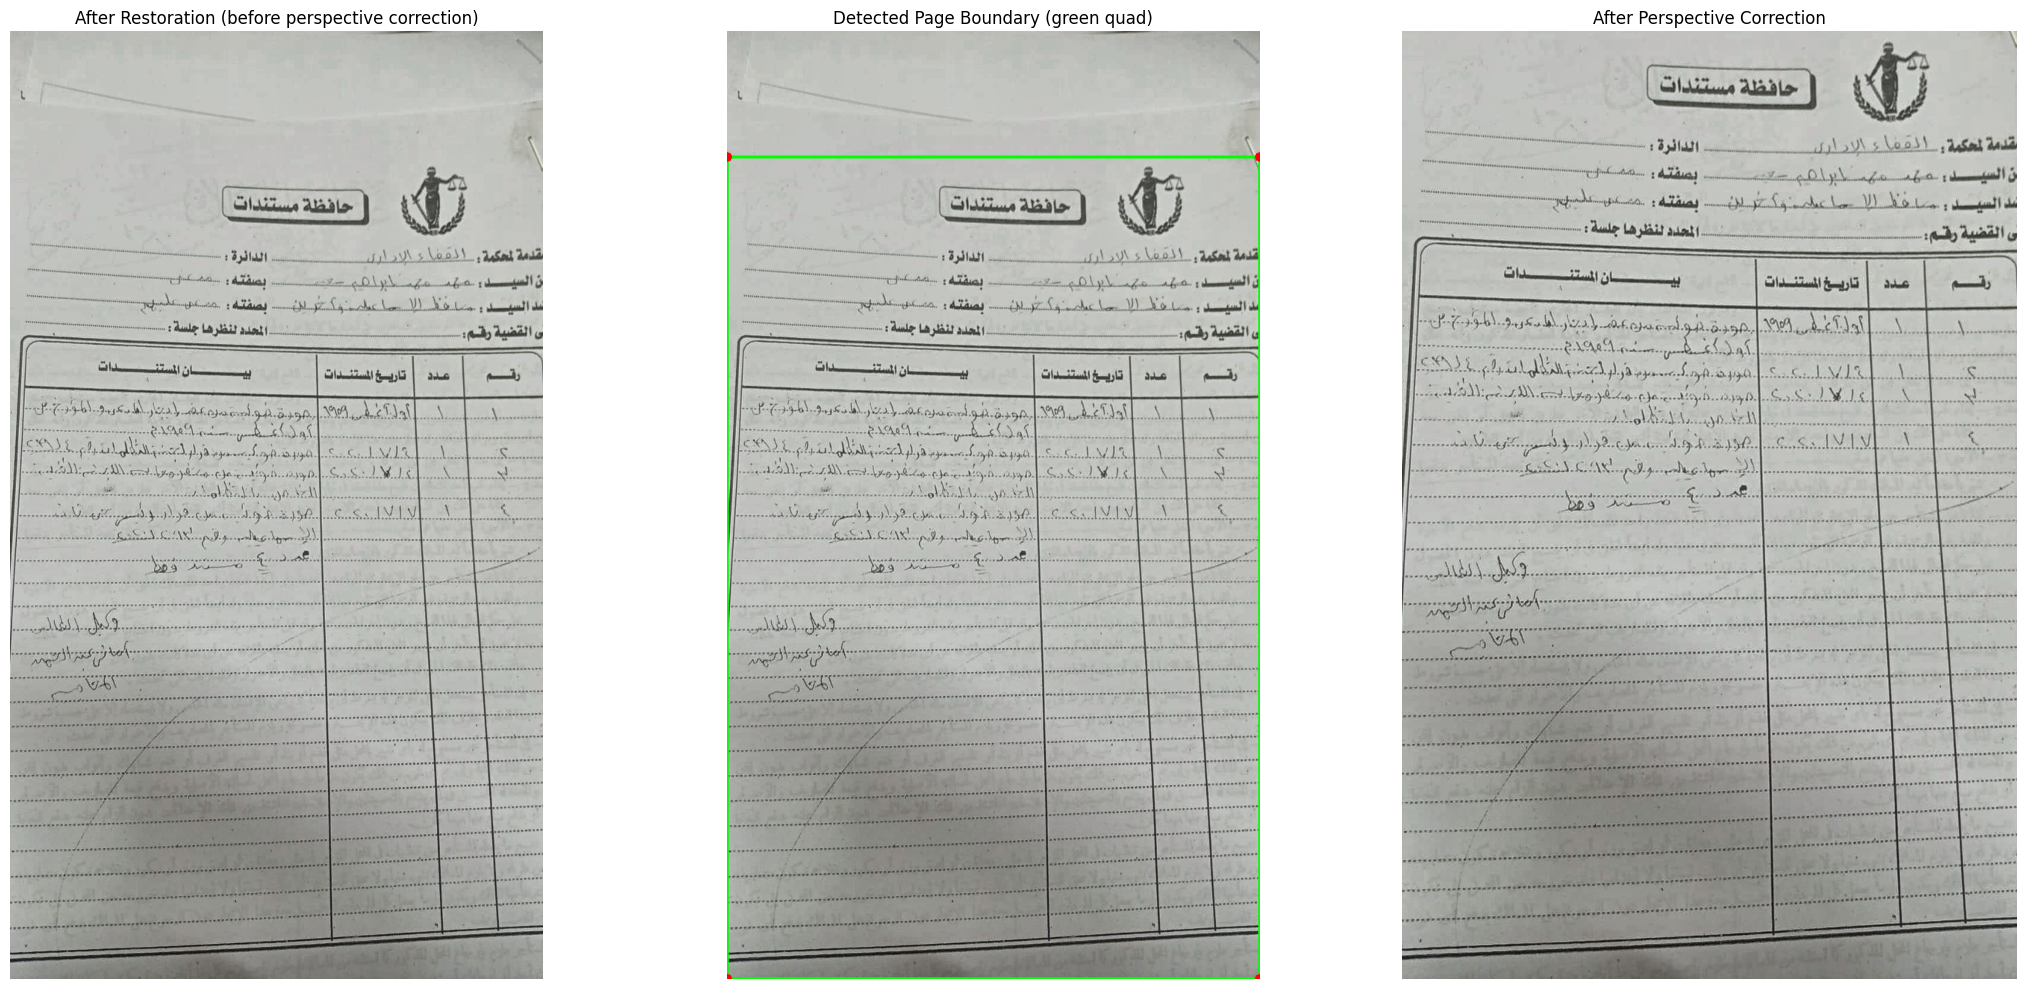

In [8]:
# Visual inspection cell -- before, detected boundary, after
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Panel 1: After restoration (before perspective correction)
axes[0].imshow(restored_pages[0])
axes[0].set_title("After Restoration (before perspective correction)")
axes[0].axis("off")

# Panel 2: Detected boundary overlay on original
overlay = np.array(restored_pages[0]).copy()
page_quad = detect_page_contour(np.array(restored_pages[0]))
if page_quad is None:
    page_quad = detect_page_threshold(np.array(restored_pages[0]))
if page_quad is not None:
    pts = expand_quad(page_quad.astype(np.float32), overlay.shape, margin_pct=0.02)
    pts_int = pts.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(overlay, [pts_int], isClosed=True, color=(0, 255, 0), thickness=3)
    for pt in pts.astype(np.int32):
        cv2.circle(overlay, tuple(pt), 8, (255, 0, 0), -1)
    axes[1].set_title("Detected Page Boundary (green quad)")
else:
    axes[1].set_title("No Page Boundary Detected")
axes[1].imshow(overlay)
axes[1].axis("off")

# Panel 3: After perspective correction
axes[2].imshow(corrected_pages[0])
axes[2].set_title("After Perspective Correction")
axes[2].axis("off")

plt.tight_layout()
plt.show()


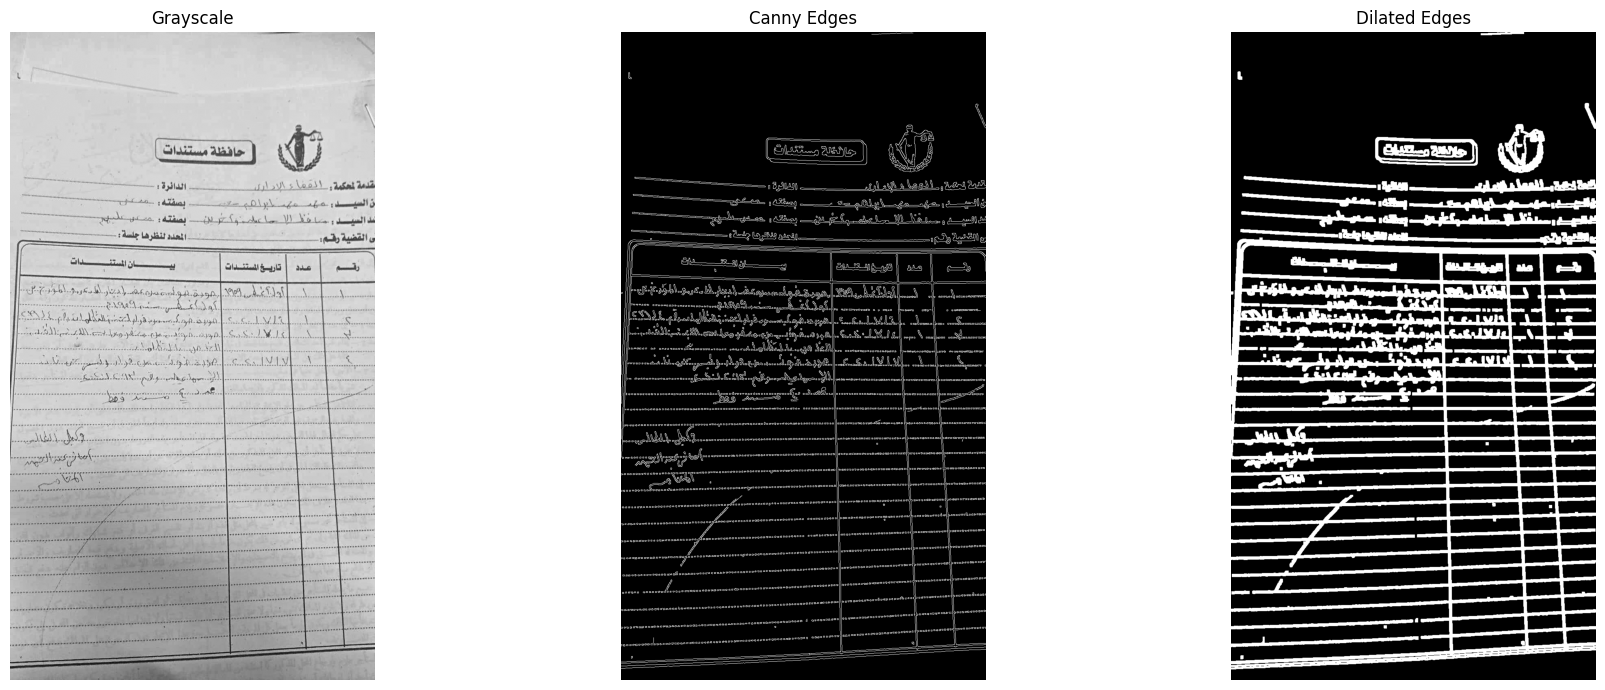

Image size: 899x1599 (area=1,437,501)
Contour 0: area=644,878 (44.9%), vertices=16
Contour 1: area=15,986 (1.1%), vertices=5
Contour 2: area=9,030 (0.6%), vertices=10
Contour 3: area=4,967 (0.3%), vertices=3
Contour 4: area=4,572 (0.3%), vertices=4


In [9]:
# Diagnostic: inspect edge detection intermediate results
test_img = np.array(restored_pages[0])
gray = cv2.cvtColor(test_img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
edges_dilated = cv2.dilate(edges, kernel, iterations=2)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges')
axes[1].axis('off')

axes[2].imshow(edges_dilated, cmap='gray')
axes[2].set_title('Dilated Edges')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Show contour detection result
contours, _ = cv2.findContours(edges_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
h, w = test_img.shape[:2]
img_area = w * h
print(f'Image size: {w}x{h} (area={img_area:,})')
for i, cnt in enumerate(contours[:5]):
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    print(f'Contour {i}: area={area:,.0f} ({100*area/img_area:.1f}%), vertices={len(approx)}')
